# Assignment 4
This project implements generative modelling between three simple 2D distributions representing different "animals". We work with two-pixel images, where each sample is a point in 2D space. The dog distribution is uniform within the square defined by corners (-1,1) and (-2,2). The cat distribution is uniform within the square defined by corners (2,-2) and (3,-3). The Gaussian distribution follows a standard normal distribution with identity covariance matrix, scaled by a factor `s`. Our goal is to learn mappings from both Gaussians and cats to the dog distribution using flow-based generative models.

In [362]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy.spatial.distance import cdist
#import math

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Distribution Definitions (Dogs, Cats, Gaussians)

In [363]:
class SimpleDistributionDataset(Dataset):
    """Dataset to sample from simple 2D distributions."""

    def __init__(self, distribution='dog', num_samples=10000):
        self.num_samples = num_samples
        self.distribution = distribution

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if self.distribution == 'dog':
            # Uniform in square with corners (-1,1) and (-2,2), this means x in [-2, -1], y in [1, 2]
            x = torch.FloatTensor(1).uniform_(-2, -1).item()
            y = torch.FloatTensor(1).uniform_(1, 2).item()
            return torch.tensor([x, y], dtype=torch.float32)  # Shape (2)
        elif self.distribution == 'cat':
            # Uniform in square with corners (2,-2) and (3,-3), this means x in [2, 3], y in [-3, -2]
            x = torch.FloatTensor(1).uniform_(2, 3).item()
            y = torch.FloatTensor(1).uniform_(-3, -2).item()
            return torch.tensor([x, y], dtype=torch.float32)  # Shape (2)
        elif self.distribution == 'gaussian':
            # Gaussian with identity covariance scaled by s
            s = 1.0  # Can be adjusted
            return torch.randn(2) * s
        else:
            raise ValueError("Distribution must be 'dog', 'cat', or 'gaussian'")

## Neural Network Architecture
Originally created with 128 hidden dimensions and a time of 32, with one less nn layer than the current one. The current change was implemented to combat against a lack of learning from previous trials.

In [364]:
class FlowNetwork(nn.Module):
    """Neural network to model velocity field v_theta(x, t) or score."""

    def __init__(self, hidden_dim=256, time_embed_dim=64):
        super(FlowNetwork, self).__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + time_embed_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)  # Outputs velocity vector in R^2
        )

    def forward(self, x, t):
        # t is expected to be in [0, 1]
        t_embed = self.time_embed(t.unsqueeze(-1))
        net_input = torch.cat([x, t_embed], dim=-1)
        return self.net(net_input)

## First-Order Euler / Euler-Maruyama Implementation
ODE appears to function correctly with good results, however SDE results contain many outliers and is sparsely distributed. Setting the minimum sigma from 0.01 to 0.1, and a maximum sigma from 1.0 to 2.0, with an increased number of generation steps from 100 to 1000, was required to combat those issues.

In [365]:
def generate_ode(model, source_samples, num_steps=100):
    """Generate samples by solving the ODE forwards using Euler method."""
    model.eval()
    with torch.no_grad():
        x = source_samples.clone()
        dt = 1.0 / num_steps  # Positive for forward-time (t=0 to t=1)

        for i in range(num_steps):
            t = torch.ones(x.shape[0]) * (i / num_steps)  # t goes from 0 to 1
            velocity = model(x, t)
            x = x + velocity * dt

        return x

def generate_sde(model, source_samples, num_steps=1000, sigma_min=0.1, sigma_max=2.0):
    """Generate samples by solving the normal-time SDE using Euler-Maruyama."""
    model.eval()
    with torch.no_grad():
        x = source_samples.clone()
        dt = 1.0 / num_steps  # Positive for forward-time

        for i in range(num_steps):
            t = torch.ones(x.shape[0]) * (i / num_steps)
            current_sigma = sigma_max + (sigma_min - sigma_max) * t  # sigma decreases over time

            # Drift term (from reverse-time SDE)
            velocity = model(x, t)
            drift = velocity * dt

            # Diffusion term (adds noise)
            diffusion = torch.sqrt(2 * current_sigma.unsqueeze(-1) * dt) * torch.randn_like(x)

            x = x + drift + diffusion

        return x

## Score Function Approach (SDE) for Gaussian -> Dog

In [366]:
def train_score_matching(model, target_dataloader, epochs, lr=1e-3, sigma_min=0.1, sigma_max=2.0):
    """Train a model using denoising score matching (corrected)."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        # Sample from target distribution (dogs)
        x0 = next(iter(target_dataloader))

        # Sample time and noise
        t = torch.rand(x0.shape[0], 1)
        sigma = sigma_min + (sigma_max - sigma_min) * t
        noise = torch.randn_like(x0)

        # Create noisy sample (forward process)
        xt = x0 + sigma * noise

        # The score is -noise/sigma, but we train the model to predict -noise
        # This is equivalent to predicting sigma * score
        target = -noise  # Model learns to predict this

        pred = model(xt, t.squeeze(-1))
        loss = torch.mean((pred - target) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return losses

## Linear Interpolant ODE for Gaussian -> Dog (`s` = 1)

In [367]:
def train_flow_matching(model, source_dataloader, target_dataloader, epochs, lr=1e-3):
    """Train for forward generation (source→target)."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        x0 = next(iter(source_dataloader))  # Source (Gaussian/Cat)
        x1 = next(iter(target_dataloader))  # Target (Dog)

        t = torch.rand(x0.shape[0], 1)

        # Forward interpolant: t=0→source, t=1→target
        xt = (1 - t) * x0 + t * x1
        target_velocity = x1 - x0  # Points from source→target

        pred_velocity = model(xt, t.squeeze(-1))
        loss = torch.mean((pred_velocity - target_velocity) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return losses

## Performance Comparison (EMD)

In [368]:
def approximate_wasserstein(samples1, samples2):
    """Approximate Wasserstein distance between two sets of samples."""
    samples1_np = samples1.detach().numpy()
    samples2_np = samples2.detach().numpy()

    # Simple approximation: mean minimum distance
    dist_matrix = cdist(samples1_np, samples2_np)
    return np.mean(np.min(dist_matrix, axis=1))

## Visualisation Functions

In [369]:
def plot_distributions(samples_dict, title="Distributions"):
    """Plot 2D distributions."""
    plt.figure(figsize=(12, 4))

    for idx, (name, samples) in enumerate(samples_dict.items()):
        plt.subplot(1, len(samples_dict), idx + 1)
        samples_np = samples.detach().numpy() if torch.is_tensor(samples) else samples
        plt.scatter(samples_np[:, 0], samples_np[:, 1], alpha=0.6, s=1)
        plt.title(name)
        plt.xlabel('Pixel 1')
        plt.ylabel('Pixel 2')
        plt.axis('equal')
        plt.grid(True, alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_training_loss(losses, title="Training Loss"):
    """Plot training loss curve."""
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.grid(True, alpha=0.3)
    plt.show()

## Quick Test

In [370]:
def test_model_immediately(model, source_loader, target_name, num_samples=500):
    """Test the model right after training to see if it learned anything."""
    model.eval()
    with torch.no_grad():
        source_samples = next(iter(source_loader))[:num_samples]
        generated = generate_ode(model, source_samples)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        source_np = source_samples.numpy()
        plt.scatter(source_np[:, 0], source_np[:, 1], alpha=0.6, s=1)
        plt.title('Source Distribution')
        plt.axis('equal')

        plt.subplot(1, 2, 2)
        generated_np = generated.numpy()
        plt.scatter(generated_np[:, 0], generated_np[:, 1], alpha=0.6, s=1)
        plt.title(f'Generated {target_name}')
        plt.axis('equal')

        plt.tight_layout()
        plt.show()

## SDE Outlier Helper

In [371]:
def clip_to_target_region(samples, target_loader, margin=0.5):
    """Clip generated samples to be within target distribution region + margin."""
    target_samples = next(iter(target_loader))

    # Calculate target region bounds
    x_min, x_max = target_samples[:, 0].min(), target_samples[:, 0].max()
    y_min, y_max = target_samples[:, 1].min(), target_samples[:, 1].max()

    # Apply clipping with margin
    clipped_samples = samples.clone()
    clipped_samples[:, 0] = torch.clamp(samples[:, 0], x_min - margin, x_max + margin)
    clipped_samples[:, 1] = torch.clamp(samples[:, 1], y_min - margin, y_max + margin)

    return clipped_samples

## Main Function / Test

Original Distributions:


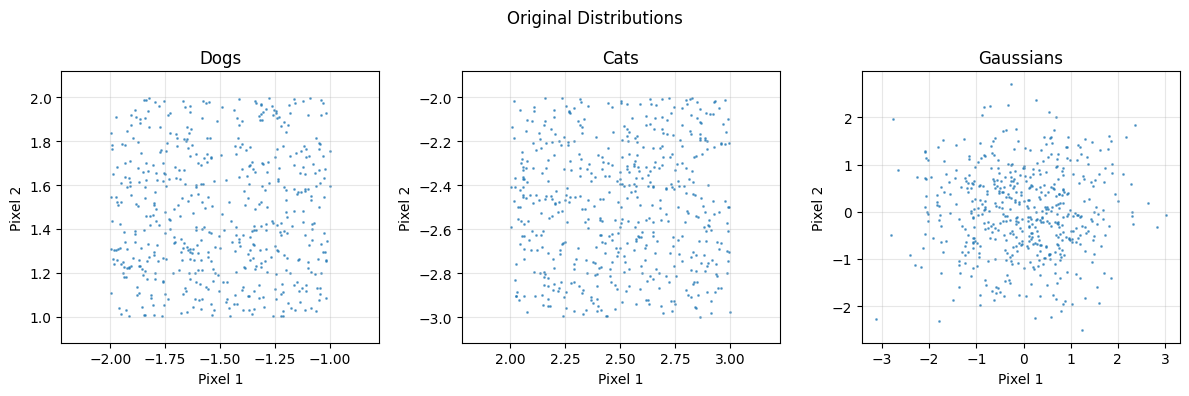


--- Training ODE: Gaussian -> Dog ---
Epoch 0, Loss: 3.527888
Epoch 500, Loss: 0.492294
Epoch 1000, Loss: 0.570803
Epoch 1500, Loss: 0.501791
Epoch 2000, Loss: 0.430391
Epoch 2500, Loss: 0.487636
Epoch 3000, Loss: 0.463790
Epoch 3500, Loss: 0.500953
Epoch 4000, Loss: 0.412319
Epoch 4500, Loss: 0.424496
Epoch 5000, Loss: 0.460211


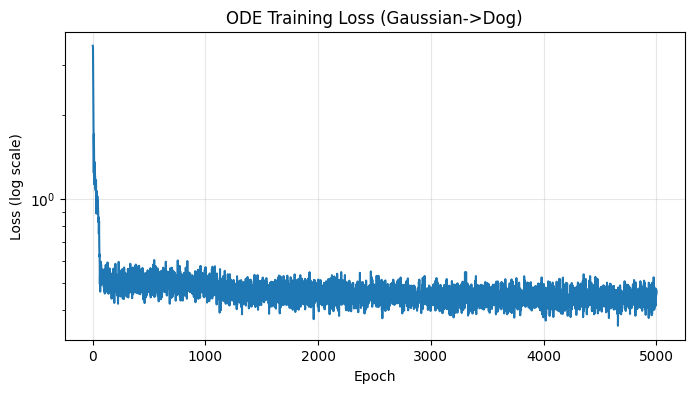


--- Immediate Test: ODE Gaussian -> Dog ---


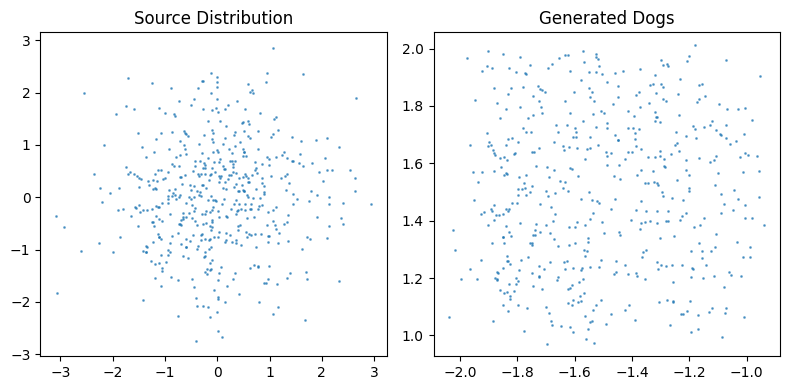


--- Training SDE: Gaussian -> Dog ---
Epoch 0, Loss: 1.021195
Epoch 500, Loss: 0.166698
Epoch 1000, Loss: 0.198213
Epoch 1500, Loss: 0.160188
Epoch 2000, Loss: 0.173386
Epoch 2500, Loss: 0.194523
Epoch 3000, Loss: 0.131739
Epoch 3500, Loss: 0.156485
Epoch 4000, Loss: 0.156942
Epoch 4500, Loss: 0.173087
Epoch 5000, Loss: 0.161918


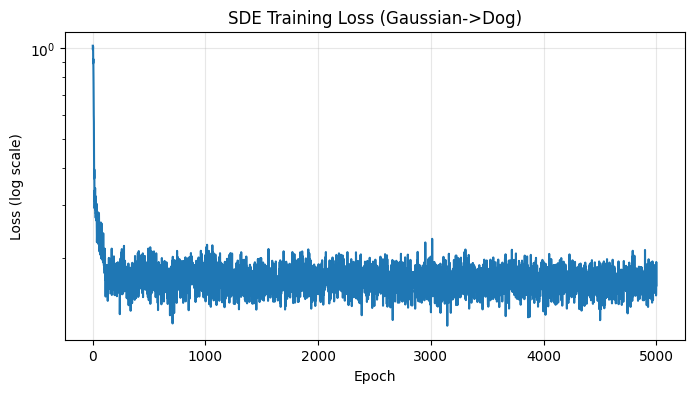


--- Immediate Test: SDE Gaussian -> Dog ---


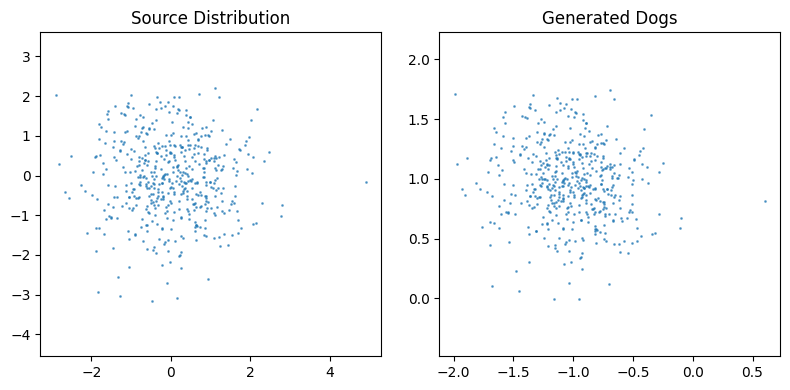


--- Training ODE: Cat -> Dog ---
Epoch 0, Loss: 16.022449
Epoch 500, Loss: 0.174232
Epoch 1000, Loss: 0.176353
Epoch 1500, Loss: 0.166052
Epoch 2000, Loss: 0.141924
Epoch 2500, Loss: 0.142803
Epoch 3000, Loss: 0.135298
Epoch 3500, Loss: 0.135072
Epoch 4000, Loss: 0.129324
Epoch 4500, Loss: 0.140112
Epoch 5000, Loss: 0.126448


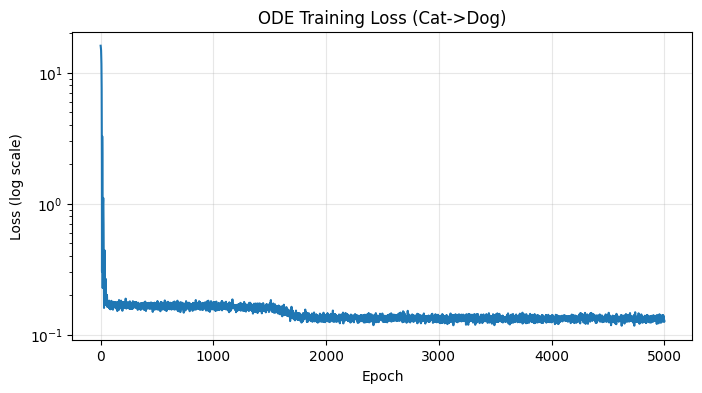


--- Immediate Test: Cat -> Dog ---


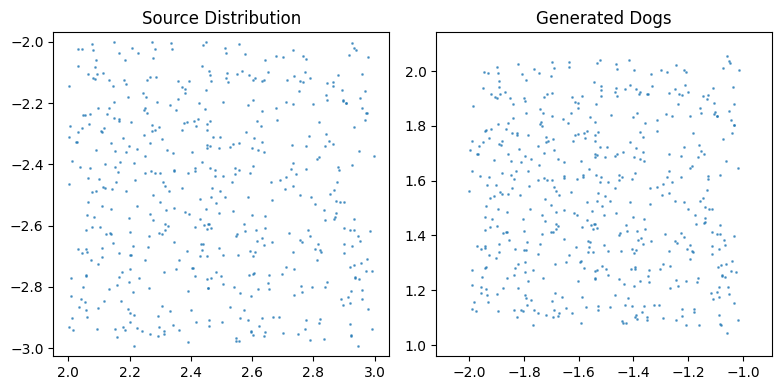


--- Generating Samples ---
Generated Distributions - ODE (Gaussian->Dog):


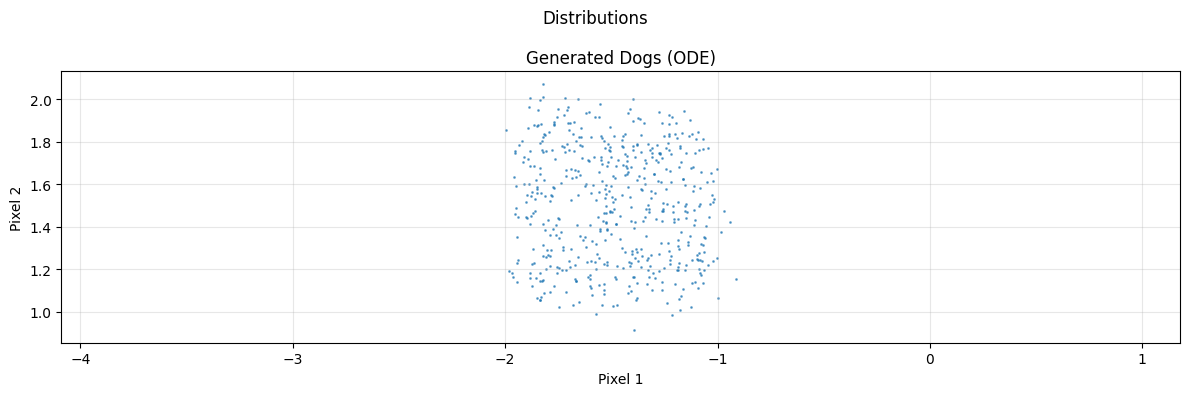

Generated Distributions - SDE (Gaussian->Dog):


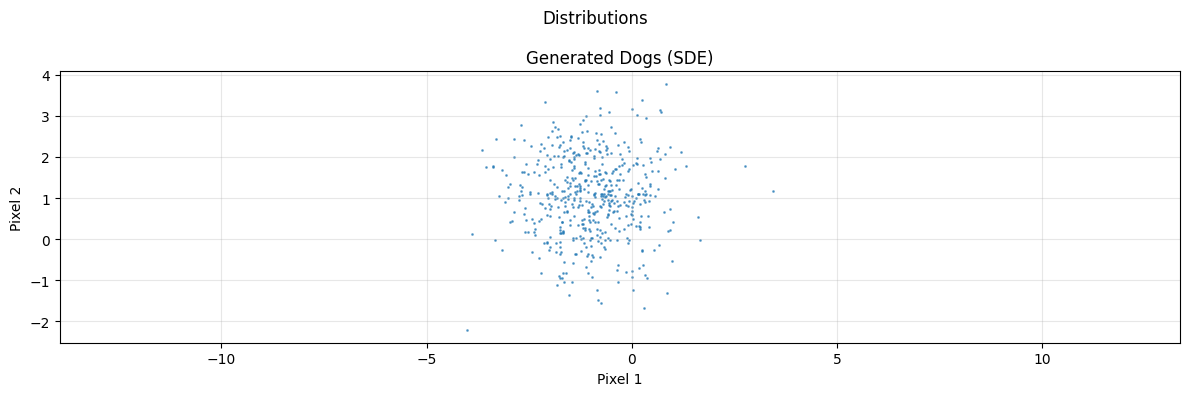

Generated Distributions - ODE (Cat->Dog):


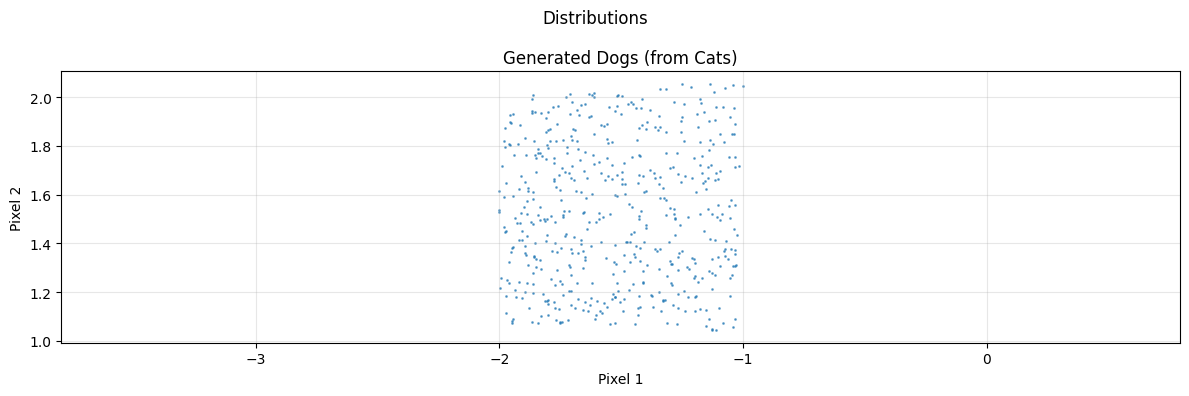

Comparison: ODE vs SDE for Gaussian->Dog


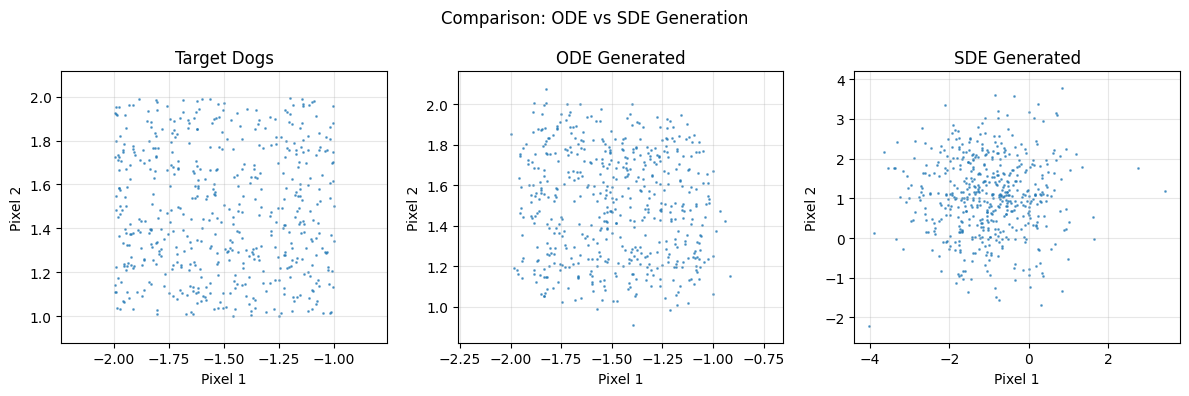

Comparison: Target vs ODE for Cat->Dog


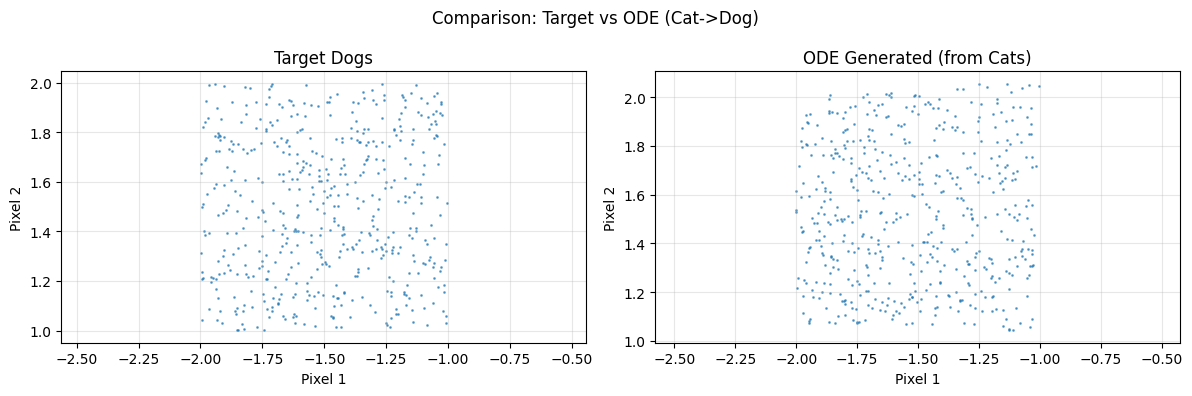


--- Performance Comparison ---
Wasserstein Distance - ODE: 0.0248
Wasserstein Distance - SDE: 0.0675
Test complete.


In [372]:
if __name__ == "__main__":
    # Create datasets and dataloaders
    batch_size = 512

    dog_dataset = SimpleDistributionDataset('dog', 10000)
    cat_dataset = SimpleDistributionDataset('cat', 10000)
    gaussian_dataset = SimpleDistributionDataset('gaussian', 10000)

    dog_loader = DataLoader(dog_dataset, batch_size=batch_size, shuffle=True)
    cat_loader = DataLoader(cat_dataset, batch_size=batch_size, shuffle=True)
    gaussian_loader = DataLoader(gaussian_dataset, batch_size=batch_size, shuffle=True)

    # Visualise original distributions
    print("Original Distributions:")
    original_samples = {
        'Dogs': next(iter(dog_loader)),
        'Cats': next(iter(cat_loader)),
        'Gaussians': next(iter(gaussian_loader))
    }
    plot_distributions(original_samples, "Original Distributions")

    # Experiment 1: Gaussian -> Dog using Flow Matching (ODE)
    print("\n--- Training ODE: Gaussian -> Dog ---")
    model_ode_g2d = FlowNetwork()
    losses_ode_g2d = train_flow_matching(model_ode_g2d, gaussian_loader, dog_loader, epochs=5001)
    plot_training_loss(losses_ode_g2d, "ODE Training Loss (Gaussian->Dog)")

    print("\n--- Immediate Test: ODE Gaussian -> Dog ---")
    test_model_immediately(model_ode_g2d, gaussian_loader, "Dogs")

    # Experiment 2: Gaussian -> Dog using Score Matching (SDE)
    print("\n--- Training SDE: Gaussian -> Dog ---")
    model_sde_g2d = FlowNetwork()
    losses_sde_g2d = train_score_matching(model_sde_g2d, dog_loader, epochs=5001)
    plot_training_loss(losses_sde_g2d, "SDE Training Loss (Gaussian->Dog)")

    print("\n--- Immediate Test: SDE Gaussian -> Dog ---")
    test_model_immediately(model_sde_g2d, gaussian_loader, "Dogs")

    # Experiment 3: Cat -> Dog using Flow Matching (ODE)
    print("\n--- Training ODE: Cat -> Dog ---")
    model_ode_c2d = FlowNetwork()
    losses_ode_c2d = train_flow_matching(model_ode_c2d, cat_loader, dog_loader, epochs=5001)
    plot_training_loss(losses_ode_c2d, "ODE Training Loss (Cat->Dog)")

    print("\n--- Immediate Test: Cat -> Dog ---")
    test_model_immediately(model_ode_c2d, cat_loader, "Dogs")

    # Generate samples from trained models
    print("\n--- Generating Samples ---")
    num_test_samples = 2000

    # Source samples for generation
    gaussian_source = next(iter(gaussian_loader))[:num_test_samples]
    cat_source = next(iter(cat_loader))[:num_test_samples]

    # Generate from all models
    generated_ode_g2d = generate_ode(model_ode_g2d, gaussian_source)
    generated_sde_g2d = generate_sde(model_sde_g2d, gaussian_source)
    generated_ode_c2d = generate_ode(model_ode_c2d, cat_source)
    #generated_sde_g2d = clip_to_target_region(generated_sde_g2d, dog_loader, margin=0.5)

    # Visualise results
    print("Generated Distributions - ODE (Gaussian->Dog):")
    plot_distributions({'Generated Dogs (ODE)': generated_ode_g2d})

    print("Generated Distributions - SDE (Gaussian->Dog):")
    plot_distributions({'Generated Dogs (SDE)': generated_sde_g2d})

    print("Generated Distributions - ODE (Cat->Dog):")
    plot_distributions({'Generated Dogs (from Cats)': generated_ode_c2d})

    # Compare ODE vs SDE for Gaussian->Dog
    print("Comparison: ODE vs SDE for Gaussian->Dog")
    comparison_samples = {
        'Target Dogs': next(iter(dog_loader))[:num_test_samples],
        'ODE Generated': generated_ode_g2d,
        'SDE Generated': generated_sde_g2d
    }
    plot_distributions(comparison_samples, "Comparison: ODE vs SDE Generation")

    # Compare ODE to target for Cat->Dog
    print("Comparison: Target vs ODE for Cat->Dog")
    comparison_samples = {
        'Target Dogs': next(iter(dog_loader))[:num_test_samples],
        'ODE Generated (from Cats)': generated_ode_c2d,
    }
    plot_distributions(comparison_samples, "Comparison: Target vs ODE (Cat->Dog)")

    # Quantitative comparison using Wasserstein distance (approximate)
    target_dogs = next(iter(dog_loader))[:num_test_samples]
    w_ode = approximate_wasserstein(target_dogs, generated_ode_g2d)
    w_sde = approximate_wasserstein(target_dogs, generated_sde_g2d)

    print(f"\n--- Performance Comparison ---")
    print(f"Wasserstein Distance - ODE: {w_ode:.4f}")
    print(f"Wasserstein Distance - SDE: {w_sde:.4f}")

    # Plot some example "images" (2D points)
    # print("\n--- Example 'Images' ---")
    # example_samples = {
    #     'Example Dogs': next(iter(dog_loader))[:100],
    #     'Example Cats': next(iter(cat_loader))[:100],
    #     'Example Gaussians': next(iter(gaussian_loader))[:100]
    # }
    # plot_distributions(example_samples, "Example Two-Pixel 'Images'")

    print("Test complete.")